# 📞 Telemarketing Campaign Analysis

### **Overview**
Telemarketing phone calls are a popular **direct marketing strategy** due to their **low cost** and potential effectiveness. However, success depends heavily on **targeting the right clients**. 

This dataset provides insights into the **success of telemarketing calls** for selling a specific bank product. It includes **various types of features** categorized into **client demographics, banking history, campaign details, and economic indicators**.

---

## **📌 Dataset Features**

### **1️⃣ Client Information**
- **`age`**: Age of the potential client *(numeric)*
- **`job`**: Type of job *(e.g., admin., blue-collar, entrepreneur, housemaid, etc.)*
- **`marital_status`**: Marital status *(married, single, unknown)*
- **`education`**: Education level *(e.g., basic.4y, high.school, illiterate, etc.)*

---

### **2️⃣ Client-Bank Relationship**
- **`default`**: Does the client have **credit in default?** *(yes, no, unknown)*
- **`housing`**: Does the client have a **housing loan?** *(yes, no, unknown)*
- **`loan`**: Does the client have a **personal loan?** *(yes, no, unknown)*

---

### **3️⃣ Campaign Information**
- **`contact`**: Communication type *(cellular, telephone)*
- **`month`**: Last contact month *(jan, feb, ..., dec)*
- **`day_of_week`**: Last contact day *(mon, tue, ..., fri)*
- **`duration`**: Duration of the last contact **(in seconds)**
- **`campaign`**: Number of contacts made **during this campaign**
- **`pdays`**: Days passed since the last contact *(999 if never contacted before)*
- **`previous`**: Number of contacts made **before this campaign**
- **`poutcome`**: Outcome of the previous campaign *(failure, nonexistent, success)*

---

### **4️⃣ Economic Indicators**
- **`emp.var.rate`**: Employment variation rate *(last quarter)*
- **`cons.price.idx`**: Consumer price index *(last month)*
- **`cons.conf.idx`**: Consumer confidence index *(monthly)*
- **`euribor3m`**: **Euro Interbank Offered Rate** *(daily)*
- **`nr.employed`**: **Number of employees** in the last quarter

---

### **💡 Key Questions for Analysis**
- What **client characteristics** influence the success of a telemarketing campaign?
- Does the **duration of the call** impact the success rate?
- How do **economic conditions** affect telemarketing outcomes?
- Can we build a **predictive model** to improve targeting and increase conversion rates?

🚀 **Next Steps:** Analyze the dataset, visualize key trends, and apply machine learning techniques to enhance telemarketing effectiveness! 📊📈


In [44]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data import

In [9]:
df = pd.read_csv('telemarketing.csv')

In [11]:
df.dtypes

age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
target              int64
dtype: object

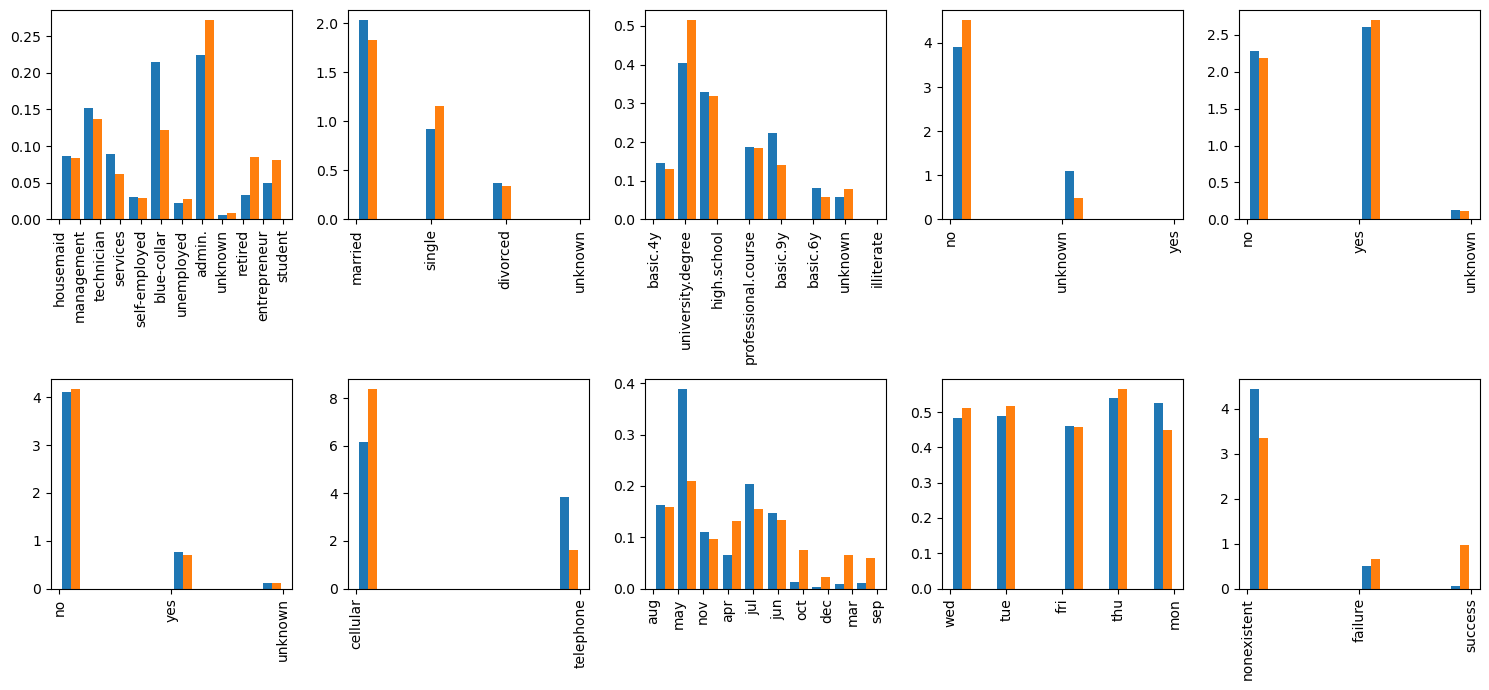

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from pathlib import Path

def plot_hist_categorical(dataframe, target, subplot, target_values=None, file_path=None):
    """
    Plots histograms for categorical features grouped by target values.
    
    Parameters:
    -----------
    dataframe : pd.DataFrame
        The input dataframe containing categorical variables.
    target : str
        The target column name in the dataframe.
    subplot : tuple
        A tuple (rows, cols) specifying the subplot layout.
    target_values : list, optional
        List of two unique values in the target column to compare. Default is [0, 1].
    file_path : str, optional
        If provided, saves the plot at the specified file path.
    
    Returns:
    --------
    None
    """
    if target_values is None:
        target_values = dataframe[target].unique()[:2]  # Automatically detect first two target values
    
    # Select categorical columns
    df_categorical = dataframe.select_dtypes(include=['object'])
    
    df_categorical = dataframe.select_dtypes(include=['object'])
    df_1 = df_categorical[dataframe[target] == target_values[0]]  # records wih target==0
    df_2 = df_categorical[dataframe[target] == target_values[1]]
    fig, axes = plt.subplots(subplot[0], subplot[1], figsize=[15, 7])
    axes = axes.flatten()

    fig.tight_layout(h_pad=5, w_pad=3)

    for i, column in enumerate(df_categorical.columns):
        if i >= len(axes):  # Prevent index error if there are more columns than subplots
            break
        plt.sca(axes[i])  # Set the current axis
        plt.hist([df_1[column], df_2[column]], density=True)
        plt.xticks(rotation=90)
    plt.tight_layout()
    
    # Save figure if file_path is provided
    if file_path:
        file_dir = Path(file_path).parent
        if not os.path.exists(file_dir):
            os.makedirs(file_dir)
        plt.savefig(file_path, bbox_inches='tight')

    plt.show()


# Example usage
plot_hist_categorical(df, "target", (2, 5), target_values=[0, 1])


In [33]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
target            0
dtype: int64

# Split categorical/continious variables

In [40]:
df.dtypes

age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
target              int64
dtype: object

In [38]:
df_categorical=df.select_dtypes(include=['object'])
df_categorical.head()

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome
0,admin.,married,basic.9y,no,yes,no,cellular,aug,wed,success
1,admin.,single,university.degree,no,yes,no,cellular,jun,mon,nonexistent
2,housemaid,married,basic.4y,no,no,no,cellular,aug,wed,nonexistent
3,management,single,university.degree,no,no,no,telephone,may,tue,nonexistent
4,technician,single,university.degree,no,yes,yes,cellular,nov,fri,nonexistent


In [46]:
df_numerical=df.select_dtypes(include=[np.number])
df_numerical.head()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,target
0,56,73,1,4,1,-2.9,92.201,-31.4,0.879,5076.2,1
1,52,327,1,999,0,-2.9,92.963,-40.8,1.266,5076.2,1
2,45,188,5,999,0,1.4,93.444,-36.1,4.964,5228.1,0
3,32,237,2,999,0,1.1,93.994,-36.4,4.857,5191.0,0
4,32,1162,2,999,0,-0.1,93.200,-42.0,4.021,5195.8,0


# Categorical data

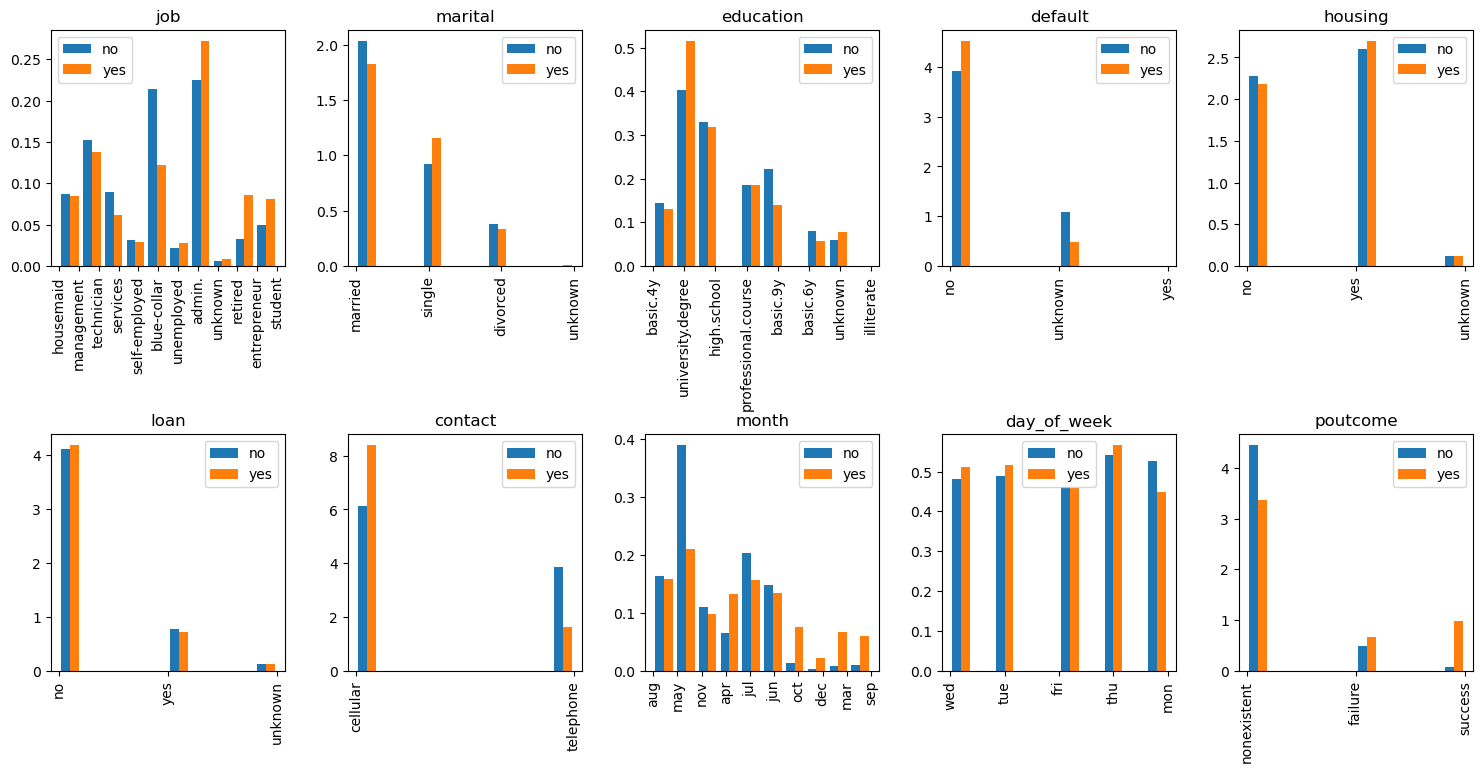

In [48]:
df_0=df_categorical[df['target']==0] # records wih target==0
df_1=df_categorical[df['target']==1] # records wih target==1


fig, axes = plt.subplots(2, 5,figsize=[15,7])
axes = axes.flatten()
fig.tight_layout(h_pad=10)

i=0
for x in df_categorical.columns:
    plt.sca(axes[i]) # set the current Axes
    plt.hist([df_0[x],df_1[x]],density=True)
    plt.xticks(rotation = 90) # Rotates X-Axis Ticks by 45-degrees
    plt.title(x)
    labels= ["no","yes"]
    plt.legend(labels)
    i+=1
plt.show()


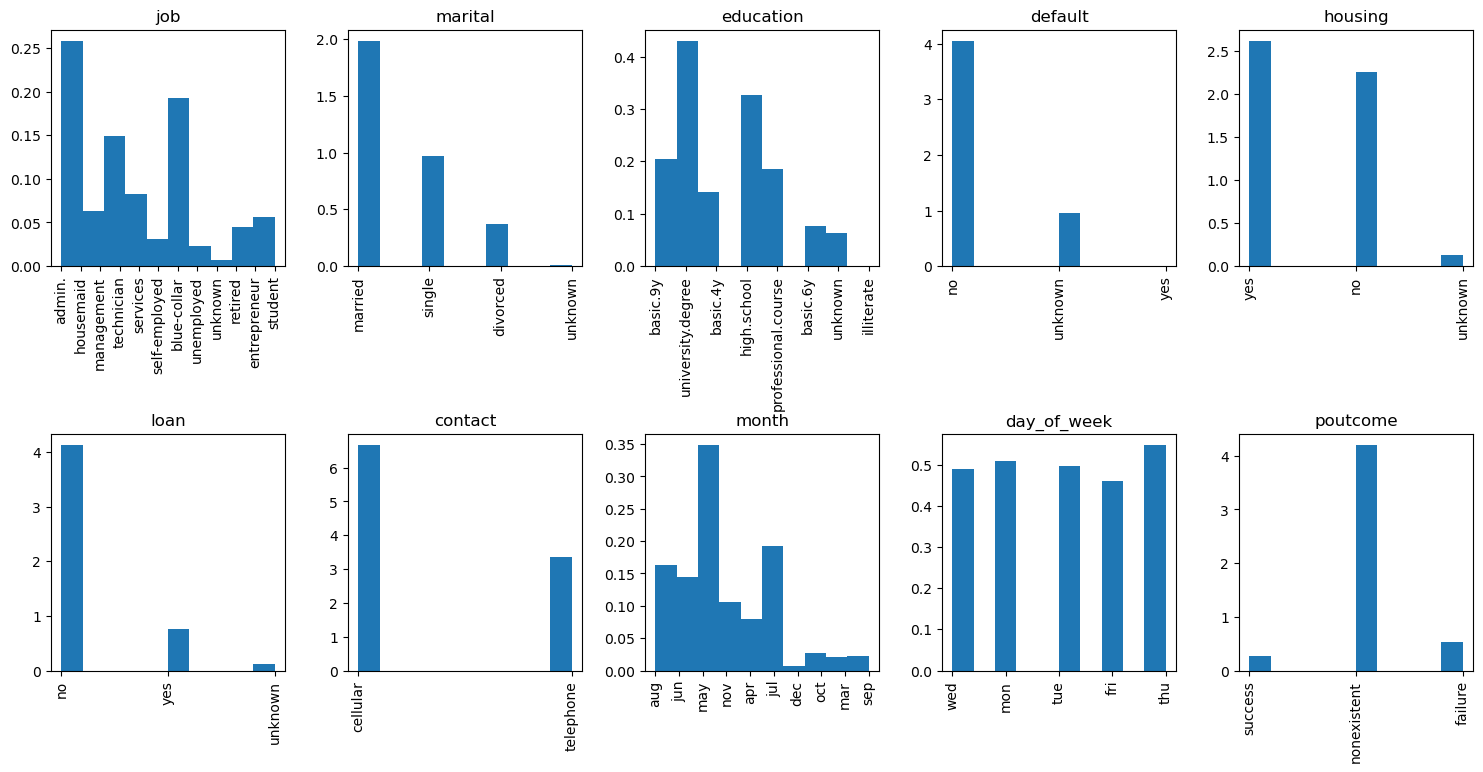

In [50]:
fig, axes = plt.subplots(2, 5,figsize=[15,7])
axes = axes.flatten()
fig.tight_layout(h_pad=10)

i=0
for x in df_categorical.columns:
    plt.sca(axes[i]) # set the current Axes
    plt.hist(df_categorical[x],density=True)
    plt.xticks(rotation = 90) # Rotates X-Axis Ticks by 45-degrees
    plt.title(x)
    i+=1
plt.show()

In [52]:
selection_categorical=['job', 'marital', 'education', 'default','contact', 'month', 'poutcome']

dummies = pd.get_dummies(df_categorical[selection_categorical]) 

dummies.tail()

,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_nonexistent,poutcome_success
14995,True,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
14996,False,False,False,True,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False
14997,False,False,False,False,True,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False
14998,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
14999,True,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,True,False


# Numerical data

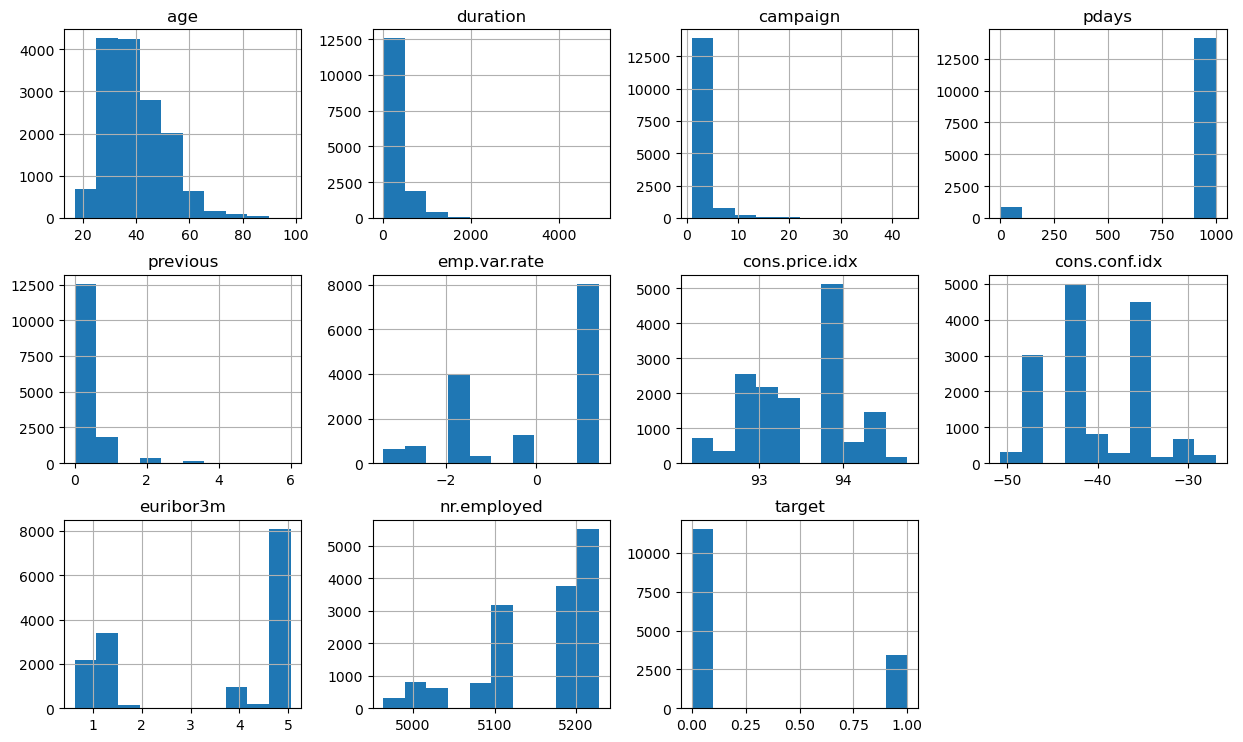

In [54]:
df_hist=df_numerical.hist(layout=(4,4), figsize=(15,12))

In [60]:
import math
pd.options.mode.chained_assignment = None # no warning on creating a new column

df_numerical['logcampaign']=df_numerical['campaign'].apply(lambda x: math.log(x+1))
df_numerical['logduration']=df_numerical['duration'].apply(lambda x: math.log(x+1))
df_numerical['logprevious']=df_numerical['previous'].apply(lambda x: math.log(x+1))

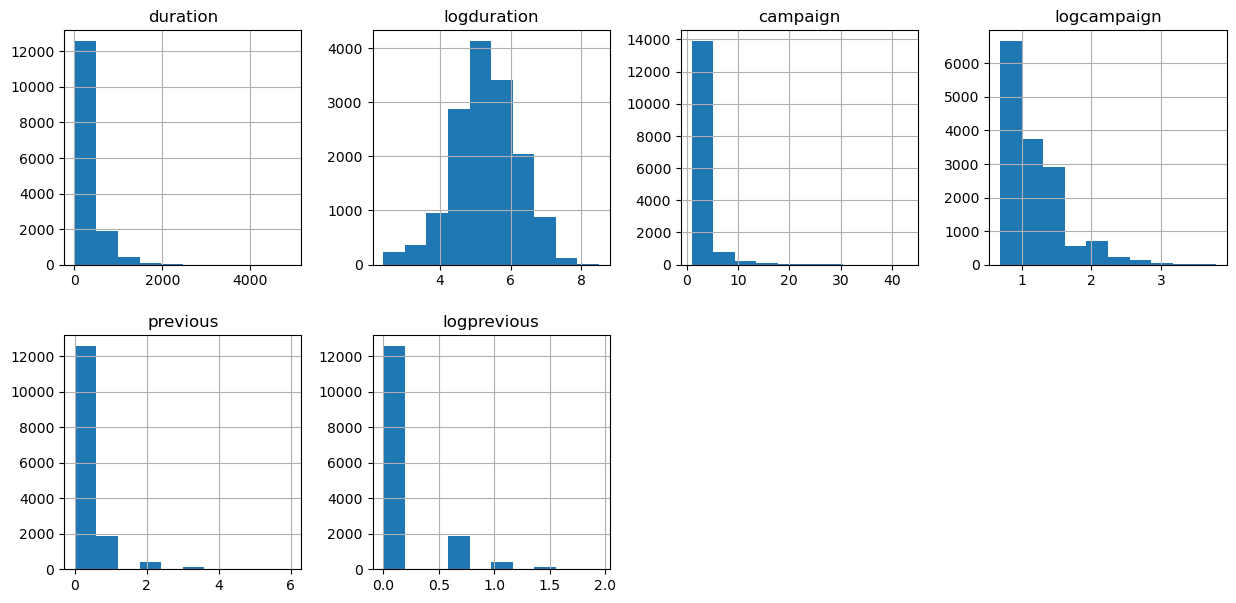

In [62]:
df_hist=df_numerical[['duration','logduration', 'campaign','logcampaign','previous','logprevious']].hist(layout=(2,4), figsize=(15,7))


In [64]:
selection_numerical=['age', 'logduration', 'logcampaign', 'pdays', 'logprevious', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'target']
df_selection_numerical=df_numerical[selection_numerical]

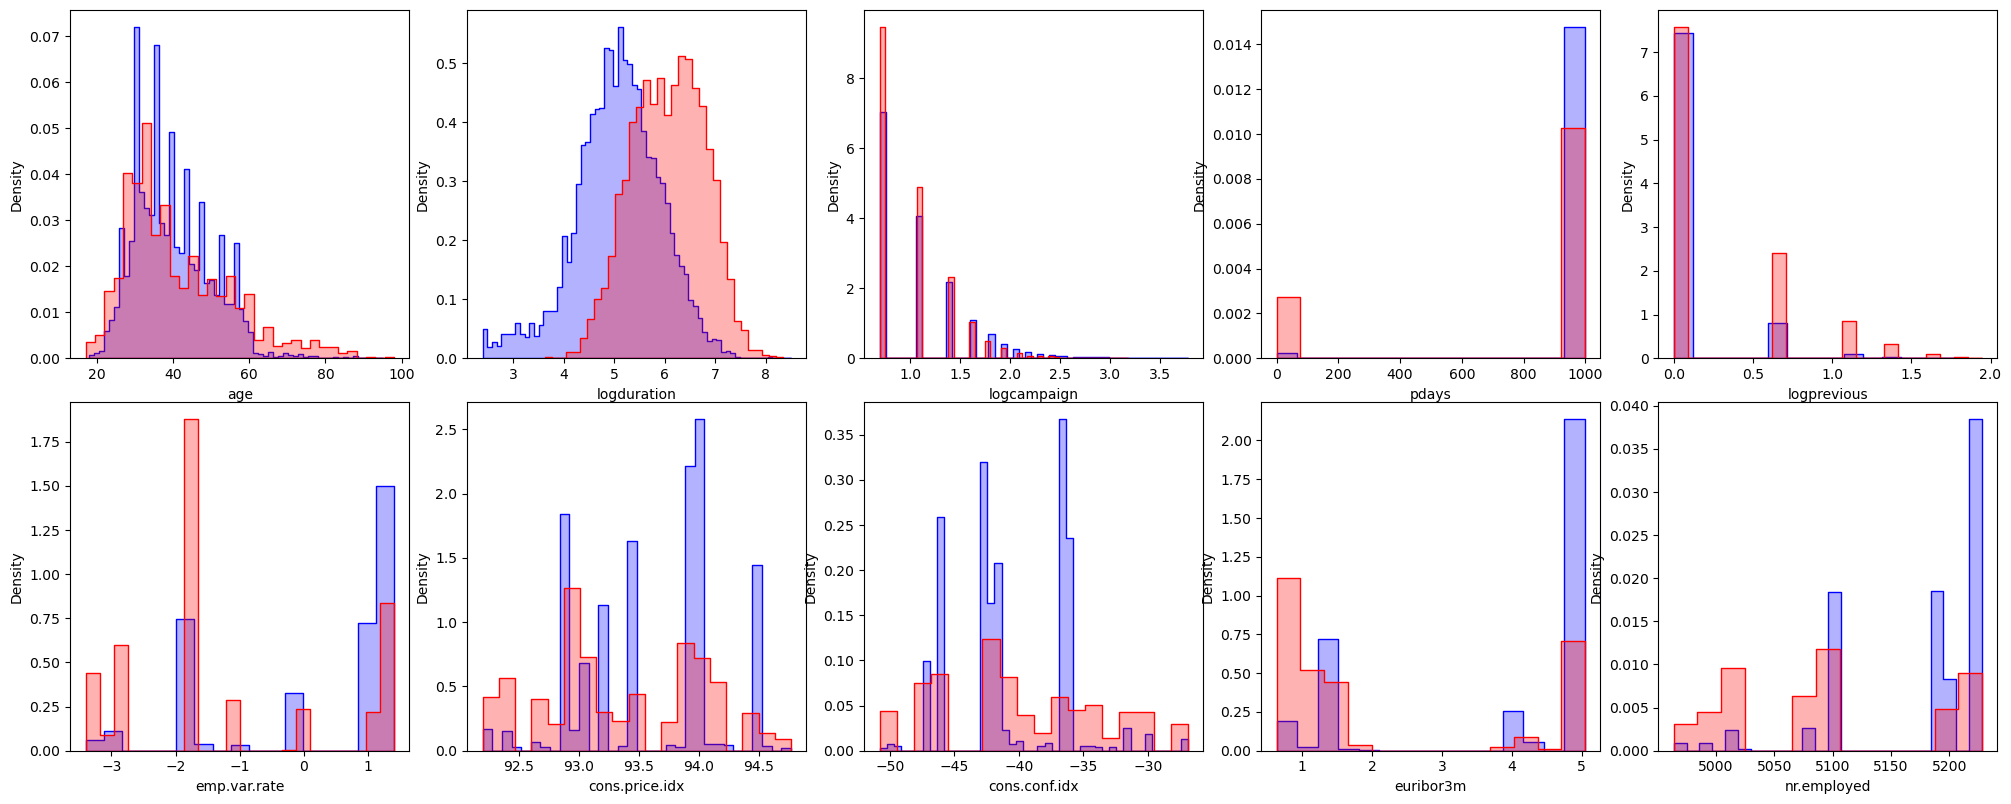

In [66]:
X0 = df_selection_numerical[df_selection_numerical['target']==0]
X1 = df_selection_numerical[df_selection_numerical['target']==1]

fig, axes = plt.subplots(ncols=5, nrows=2, figsize=(20,8))
fig.tight_layout()

for i, ax in zip(range(df_selection_numerical.columns.size), axes.flat):
    sns.histplot(X0.iloc[:,i], color="blue", ax=ax, stat='density', element="step",  alpha=0.3)
    sns.histplot(X1.iloc[:,i], color="red", ax=ax,stat='density', element="step",  alpha=0.3)
plt.show()

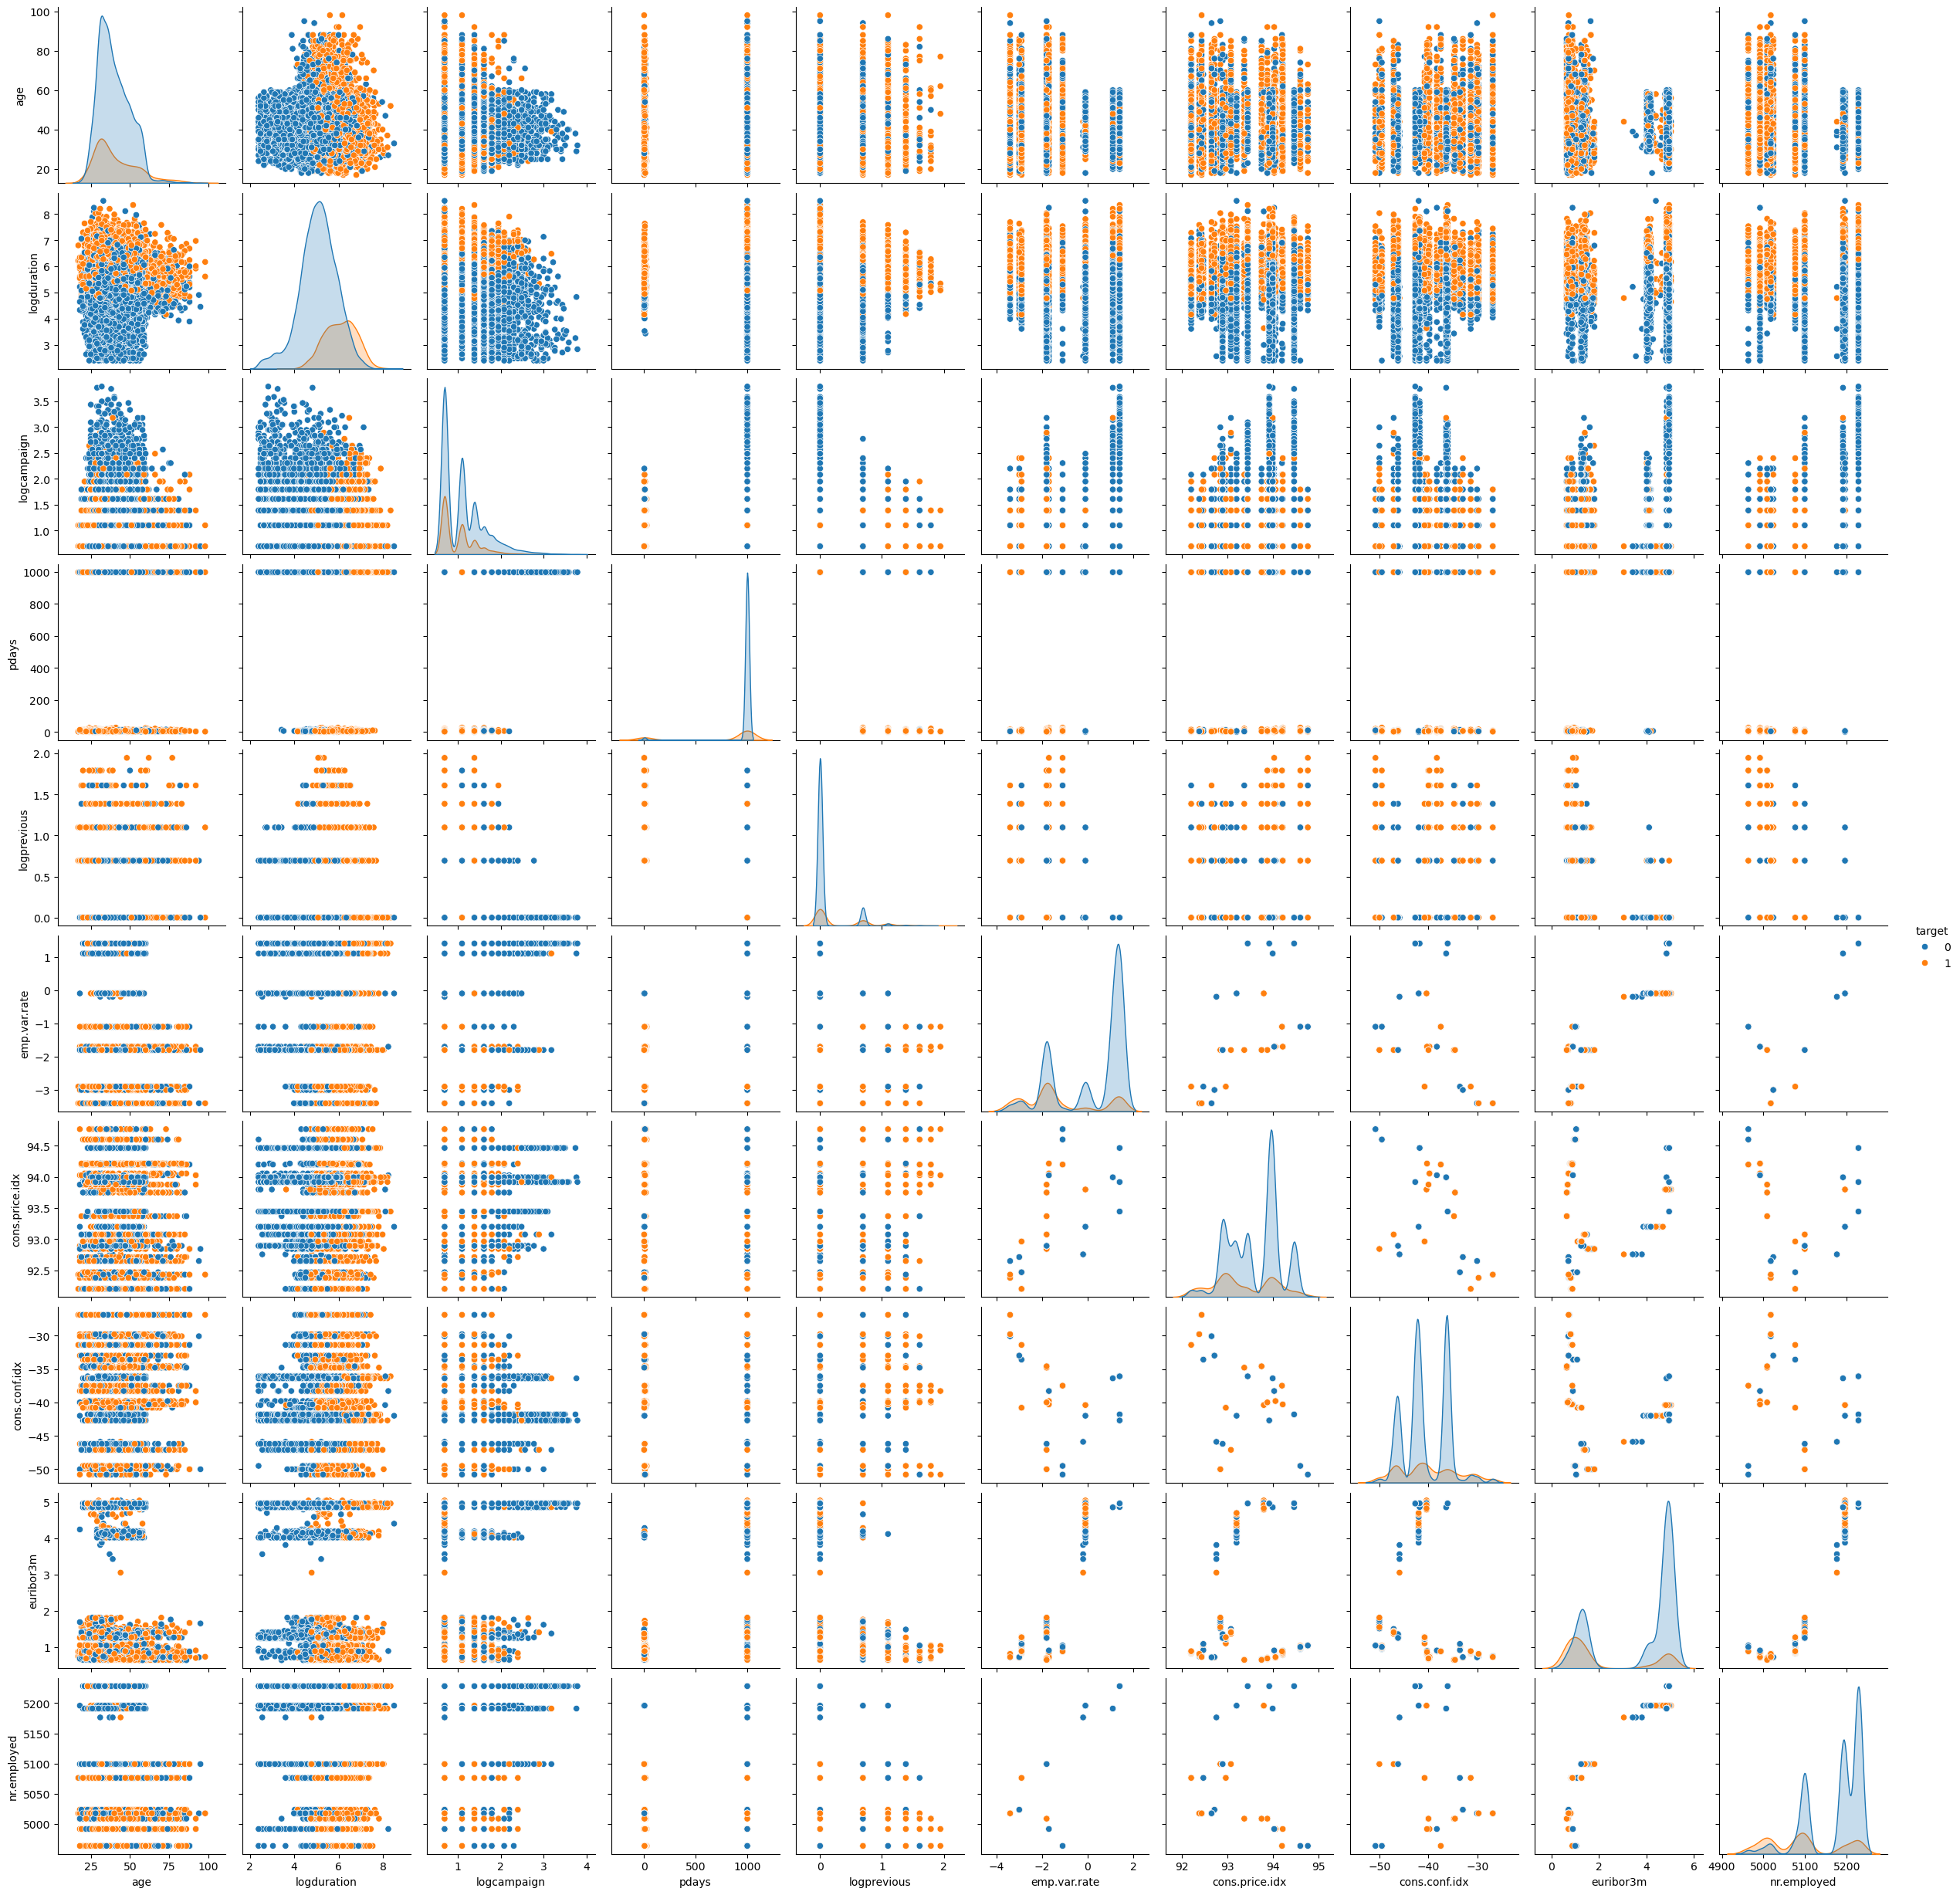

In [69]:
sns.pairplot(df_selection_numerical, hue='target')
plt.show()

# Standarize

<Axes: >

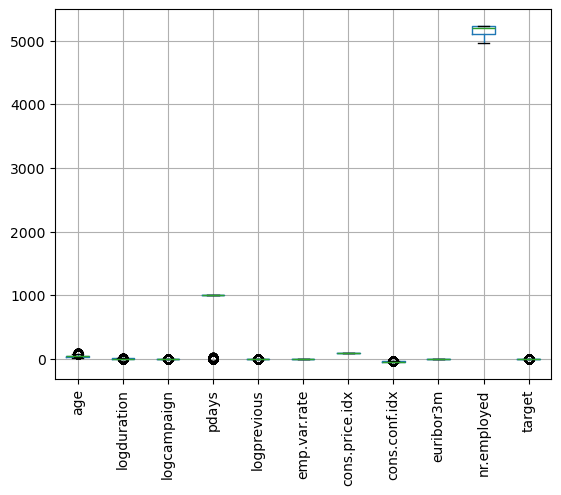

In [71]:
df_selection_numerical.boxplot(rot=90)

In [72]:
from sklearn.preprocessing import StandardScaler

independent_variables=df_selection_numerical.iloc[:,:-1] #no target

scaler = StandardScaler().fit(independent_variables) # No target
scaled_df = pd.DataFrame(scaler.transform(independent_variables))
scaled_df.columns = independent_variables.columns

scaled_df.tail()

,age,logduration,logcampaign,pdays,logprevious,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
14995,0.991498,0.255617,-0.854550,0.252494,-0.417764,0.728330,0.745760,0.830517,0.794858,0.429467
14996,1.172839,-0.211054,4.054683,0.252494,-0.417764,0.910934,0.618604,-0.467378,0.852827,0.901546
14997,0.084795,-0.224353,1.439148,0.252494,1.773840,-1.036841,-1.096339,-1.188431,-1.195936,-0.739913
14998,-0.549897,-0.971543,0.592612,0.252494,-0.417764,0.910934,-0.174453,0.892321,0.854483,0.901546
14999,0.991498,-0.251445,-0.008014,0.252494,-0.417764,-1.706389,-0.979221,-0.075950,-1.185998,-1.031304


In [76]:
# Save the scaler
import pickle
pickle.dump(scaler, open('scaler.pkl', 'wb'))

<Axes: >

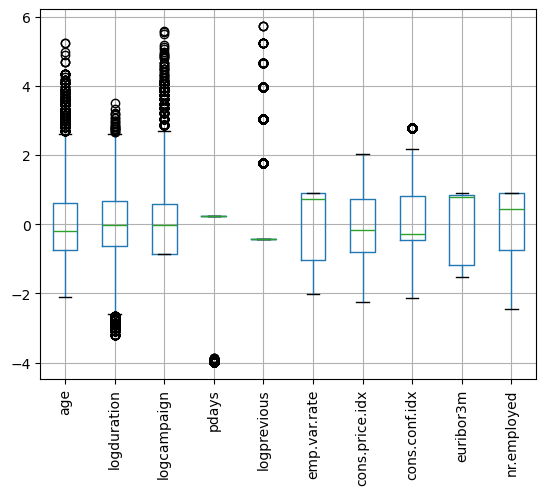

In [78]:
scaled_df.boxplot(rot=90)

In [80]:
X_numerical=scaled_df

print(dummies.shape)
print(X_numerical.shape)

(15000, 42)
(15000, 10)


In [82]:
X=pd.concat([dummies,X_numerical], axis = 1)

# Separate Train/Test sets

In [85]:
y=df['target']

In [87]:
from sklearn.model_selection import train_test_split

#SPLIT DATA INTO TRAIN AND TEST SET
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size =0.30, #by default is 75%-25%
                                                    stratify=y, #preserve target propotions 
                                                    random_state= 321) #fix random seed for replicability

print(X_train.shape, X_test.shape)

(10500, 52) (4500, 52)


# Models

In [90]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn import metrics 
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score

In [95]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, precision_score, confusion_matrix

# Ensure data is properly formatted as NumPy arrays
X_train = np.array(X_train)  # Convert to NumPy array
X_test = np.array(X_test)
y_train = np.array(y_train).ravel()  # Convert target values to a flattened NumPy array
y_test = np.array(y_test).ravel()

# KNN Classifier
classifier = KNeighborsClassifier()
parameters = {'n_neighbors': np.arange(10, 500, 20)}

def hyperp_search(classifier, parameters):
    """
    Performs hyperparameter tuning using GridSearchCV for KNN and evaluates the model.
    
    :param classifier: Scikit-learn classifier
    :param parameters: Dictionary of hyperparameters
    """
    # Grid Search with 3-Fold Cross Validation
    gs = GridSearchCV(classifier, parameters, cv=3, scoring='f1', verbose=0, n_jobs=-1)
    gs.fit(X_train, y_train)

    print(f"Best F1 Score (Train): {gs.best_score_:.4f} using {gs.best_params_}")

    # Get the best model from Grid Search
    best_model = gs.best_estimator_

    # Make predictions on test set
    y_pred = best_model.predict(X_test)
    y_pred_train = best_model.predict(X_train)

    # Print Metrics
    print(f"F1 Score      - Train: {f1_score(y_train, y_pred_train):.3f} | Test: {f1_score(y_test, y_pred):.3f}")
    print(f"Precision     - Train: {precision_score(y_train, y_pred_train):.3f} | Test: {precision_score(y_test, y_pred):.3f}")
    
    # Print Confusion Matrix
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    return best_model




In [97]:
best_knn_model = hyperp_search(classifier, parameters)

Best F1 Score (Train): 0.6164 using {'n_neighbors': 30}
F1 Score      - Train: 0.659 | Test: 0.619
Precision     - Train: 0.764 | Test: 0.733

Confusion Matrix:
[[3265  201]
 [ 481  553]]


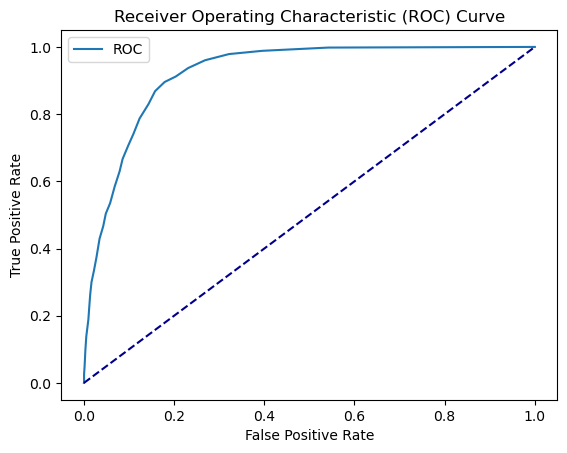

AUC: 0.92


In [99]:
model_knn = KNeighborsClassifier(n_neighbors=30)

def roc(model,X_train,y_train,X_test,y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    y_probs = model.predict_proba(X_test) #predict_proba gives the probabilities for the target (0 and 1 in your case) 

    fpr, tpr, thresholds1=metrics.roc_curve(y_test,  y_probs[:,1])

    import matplotlib.pyplot as plt
    plt.plot(fpr, tpr, label='ROC')
    plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend()
    plt.show()

    auc = metrics.roc_auc_score(y_test, y_probs[:,1])
    print('AUC: %.2f' % auc)
    return (fpr, tpr)

fpr1,tpr1=roc(model_knn,X_train,y_train,X_test,y_test)

In [103]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier()
parameters = {'criterion': ['entropy','gini'], 
              'max_depth': [4,5,6,8,10],
              'min_samples_split': [5,10,20],
              'min_samples_leaf': [5,10,20]}

best_tree = hyperp_search(classifier,parameters)

Best F1 Score (Train): 0.7373 using {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 20}
F1 Score      - Train: 0.752 | Test: 0.737
Precision     - Train: 0.748 | Test: 0.725

Confusion Matrix:
[[3173  293]
 [ 260  774]]


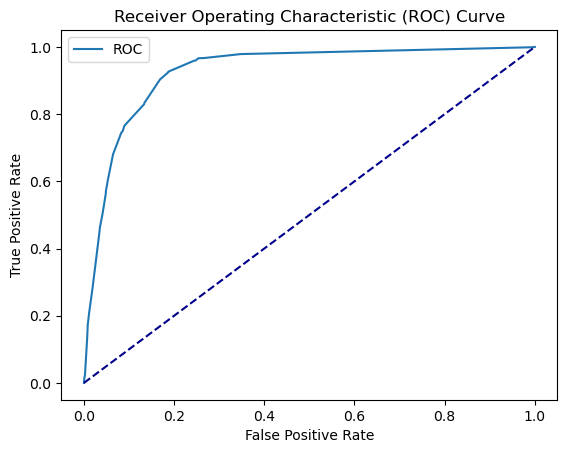

AUC: 0.93


In [109]:
model_tree = DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=5, min_samples_split=20)

fpr2,tpr2=roc(model_tree,X_train,y_train,X_test,y_test)

In [111]:
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression()
parameters = {"C":[1e-4,1e-3,1e-2,1e-1,1,10], "max_iter":[1000] }


best_LR = hyperp_search(classifier,parameters)


Best F1 Score (Train): 0.7108 using {'C': 10, 'max_iter': 1000}
F1 Score      - Train: 0.719 | Test: 0.715
Precision     - Train: 0.765 | Test: 0.746

Confusion Matrix:
[[3224  242]
 [ 324  710]]


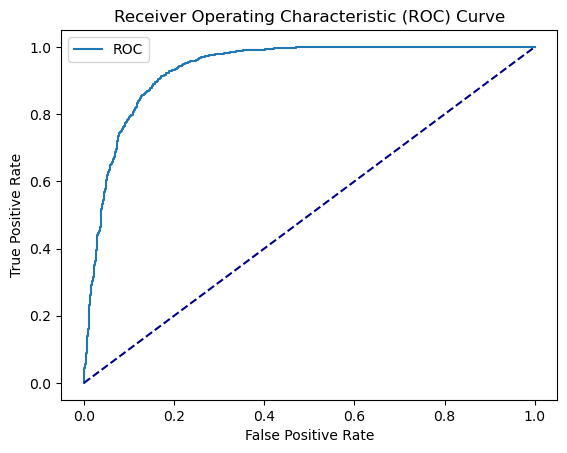

AUC: 0.93


In [113]:
model = LogisticRegression(C=10, max_iter=1000)

fpr4,tpr4=roc(model,X_train,y_train,X_test,y_test)

In [115]:
from sklearn.neural_network import MLPClassifier

classifier = MLPClassifier()
parameters = {"hidden_layer_sizes":[(10, 5),(100,20,5)],  "max_iter": [2000], "alpha": [0.001,0.1]}

best_MLP=hyperp_search(classifier,parameters)

Best F1 Score (Train): 0.7368 using {'alpha': 0.1, 'hidden_layer_sizes': (10, 5), 'max_iter': 2000}
F1 Score      - Train: 0.785 | Test: 0.742
Precision     - Train: 0.764 | Test: 0.711

Confusion Matrix:
[[3140  326]
 [ 232  802]]


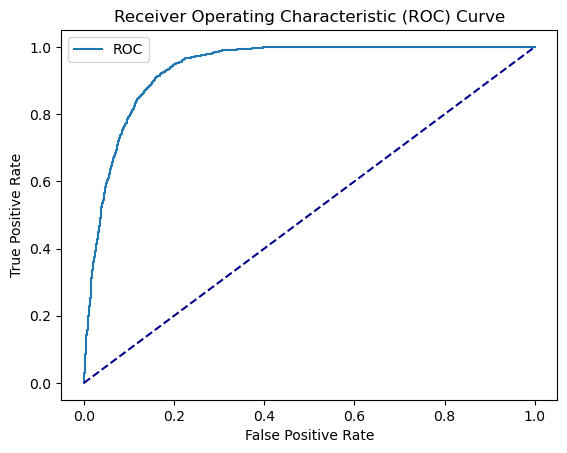

AUC: 0.94


In [119]:
model_MLP=MLPClassifier(hidden_layer_sizes=(10,5), alpha=0.1, max_iter=2000)

fpr6,tpr6=roc(model_MLP,X_train,y_train,X_test,y_test)